In [51]:
pip install pandas


[notice] A new release of pip is available: 24.3.1 -> 25.1
[notice] To update, run: /opt/homebrew/Cellar/jupyterlab/4.4.1_1/libexec/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [52]:
pip install matplotlib


[notice] A new release of pip is available: 24.3.1 -> 25.1
[notice] To update, run: /opt/homebrew/Cellar/jupyterlab/4.4.1_1/libexec/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [53]:
pip install seaborn


[notice] A new release of pip is available: 24.3.1 -> 25.1
[notice] To update, run: /opt/homebrew/Cellar/jupyterlab/4.4.1_1/libexec/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [54]:
pip install scikit-learn


[notice] A new release of pip is available: 24.3.1 -> 25.1
[notice] To update, run: /opt/homebrew/Cellar/jupyterlab/4.4.1_1/libexec/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [55]:
pip install scikit-learn xgboost


[notice] A new release of pip is available: 24.3.1 -> 25.1
[notice] To update, run: /opt/homebrew/Cellar/jupyterlab/4.4.1_1/libexec/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [56]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt

In [57]:
import seaborn as sns

In [58]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [59]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as XGBRegressor

In [60]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

In [61]:
import warnings
warnings.filterwarnings('ignore')

## Read training and test datasets

In [62]:
# helper function for reading datatset
def read_data(file_path):
    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d') # convert it to datatime

    return df

In [63]:
df_train = read_data('kospi_train.csv')
df_test = read_data('kospi_test.csv')

len(df_train), len(df_test)

(986, 244)

In [64]:
# the training dataset has daily KOSPI index from 2019 to 2022
df_train

,Date,Open,Low,High,Close,Volume
0,2019-01-02,2050.550049,2004.270020,2053.449951,2010.000000,326400
1,2019-01-03,2011.810059,1991.650024,2014.719971,1993.699951,428000
2,2019-01-04,1992.400024,1984.530029,2011.560059,2010.250000,409000
3,2019-01-07,2034.239990,2030.900024,2048.060059,2037.099976,440200
4,2019-01-08,2038.680054,2023.589966,2042.699951,2025.270020,397800
...,...,...,...,...,...,...
981,2022-12-23,2325.860107,2311.899902,2333.080078,2313.689941,367000
982,2022-12-26,2312.540039,2304.199951,2321.919922,2317.139893,427600
983,2022-12-27,2327.520020,2321.479980,2335.989990,2332.790039,448300
984,2022-12-28,2296.449951,2276.899902,2296.449951,2280.449951,405700


In [65]:
# the test dataset has daily KOSPI index in 2023
df_test

,Date,Open,Low,High,Close,Volume
0,2023-01-02,2249.949951,2222.370117,2259.879883,2225.669922,346100
1,2023-01-03,2230.979980,2180.669922,2230.979980,2218.679932,410000
2,2023-01-04,2205.979980,2198.820068,2260.060059,2255.979980,412700
3,2023-01-05,2268.199951,2252.969971,2281.389893,2264.649902,430800
4,2023-01-06,2253.399902,2253.270020,2300.620117,2289.969971,398300
...,...,...,...,...,...,...
239,2023-12-21,2598.370117,2587.159912,2610.810059,2600.020020,578300
240,2023-12-22,2617.719971,2599.510010,2621.370117,2599.510010,466000
241,2023-12-26,2609.439941,2594.649902,2612.139893,2602.590088,439500
242,2023-12-27,2599.350098,2590.080078,2613.500000,2613.500000,349700


## Part 1. Predict KOSPI of the next day.
### Train regression models to predict the next day's `close` using `Open`, `Low`, `High`, `Close`, `Volume` of previous days as predictors using *only* df_train. Cross-validate to select the best model. Evaluate the accuracy of your model using `df_test`.


In [66]:
print(f"훈련 데이터 크기: {len(df_train)}, 테스트 데이터 크기: {len(df_test)}")

훈련 데이터 크기: 986, 테스트 데이터 크기: 244


In [67]:
# 데이터 확인
print("\n훈련 데이터 샘플:")
print(df_train.head())

# 기술 통계량 확인
print("\n훈련 데이터 통계:")
print(df_train.describe())

# 결측치 확인
print("\n결측치 확인:")
print(df_train.isnull().sum())



훈련 데이터 샘플:
        Date         Open          Low         High        Close  Volume
0 2019-01-02  2050.550049  2004.270020  2053.449951  2010.000000  326400
1 2019-01-03  2011.810059  1991.650024  2014.719971  1993.699951  428000
2 2019-01-04  1992.400024  1984.530029  2011.560059  2010.250000  409000
3 2019-01-07  2034.239990  2030.900024  2048.060059  2037.099976  440200
4 2019-01-08  2038.680054  2023.589966  2042.699951  2025.270020  397800

훈련 데이터 통계:
                                Date         Open          Low         High  \
count                            986   986.000000   986.000000   986.000000   
mean   2020-12-30 22:44:03.407708160  2491.245019  2473.949038  2505.511379   
min              2019-01-02 00:00:00  1474.449951  1439.430054  1516.750000   
25%              2020-01-02 06:00:00  2141.460022  2125.494995  2153.652527   
50%              2020-12-29 12:00:00  2373.609985  2355.854980  2387.719971   
75%              2021-12-27 18:00:00  2935.392456  2910.629944  

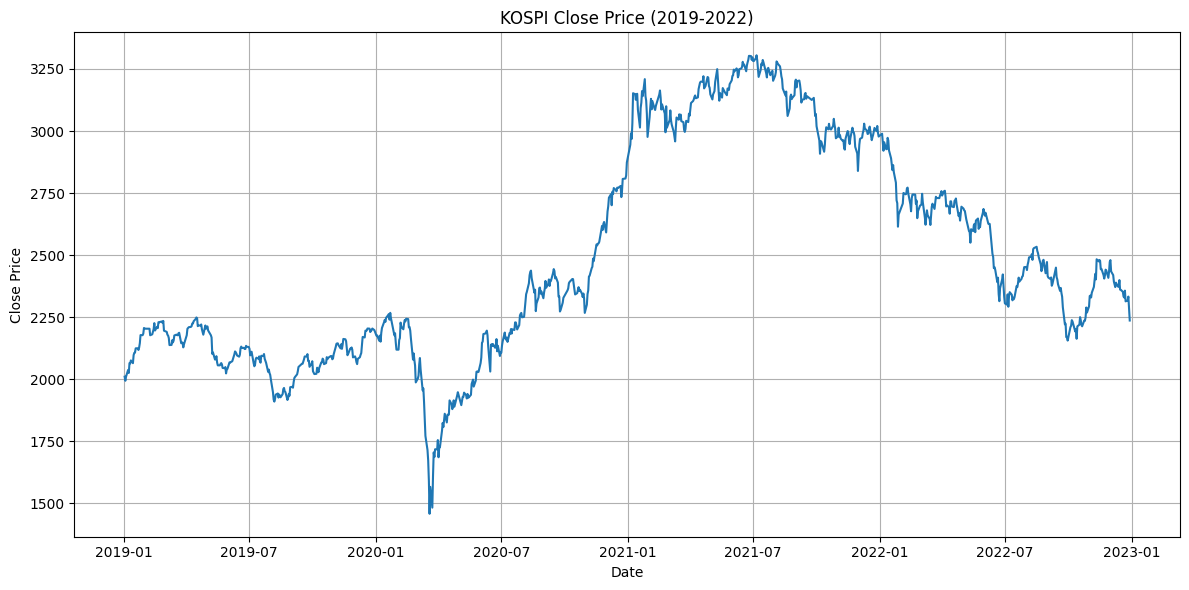

In [68]:
# 데이터 시각화 - 종가 추이
plt.figure(figsize=(12, 6))
plt.plot(df_train['Date'], df_train['Close'])
plt.title('KOSPI Close Price (2019-2022)')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True)
plt.tight_layout()
plt.savefig('kospi_close_price.png')
plt.show()

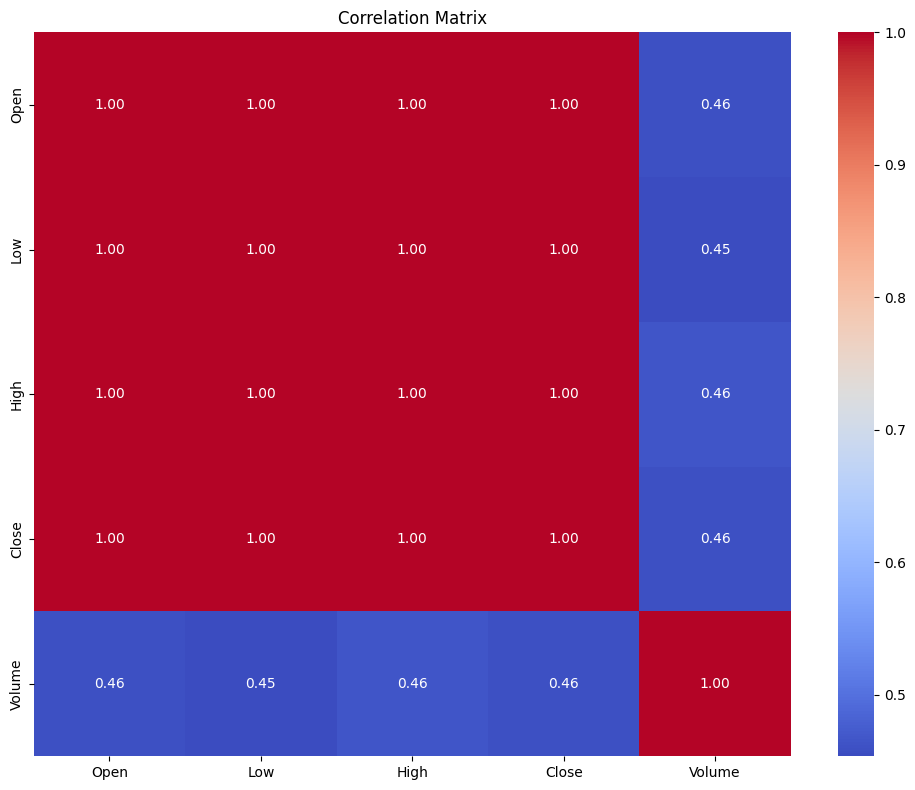

In [69]:
# 상관관계 분석
plt.figure(figsize=(10, 8))
correlation = df_train[['Open', 'Low', 'High', 'Close', 'Volume']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation_matrix.png')
plt.show()

In [70]:
# 특성 생성 함수 - Part 1의 경우 이전 날짜의 OHLCV만 사용
def create_features_part1(df):
    """
    다음 날 종가 예측을 위한 특성을 생성합니다.
    Part 1에서는 이전 날짜의 OHLCV만 사용합니다.
    """
    # 다음 날 종가를 타겟으로 설정 (shift(-1)을 사용하여 다음 날 종가를 현재 행으로 가져옴)
    df['Target'] = df['Close'].shift(-1)
    
    # 기본 특성: 이전 1일, 2일, 3일, 5일의 OHLCV
    lags = [1, 2, 3, 5]
    for lag in lags:
        df[f'Open_lag_{lag}'] = df['Open'].shift(lag)
        df[f'High_lag_{lag}'] = df['High'].shift(lag)
        df[f'Low_lag_{lag}'] = df['Low'].shift(lag)
        df[f'Close_lag_{lag}'] = df['Close'].shift(lag)
        df[f'Volume_lag_{lag}'] = df['Volume'].shift(lag)
    
    # NaN 값 제거 (시차 변수 계산 초기에 발생하는 NaN)
    df.dropna(inplace=True)
    
    return df

In [71]:
# 데이터 준비
def prepare_part1_features(train_df, test_df):
    # Part 1 특성 생성
    train_features = create_features_part1(train_df.copy())
    test_features = create_features_part1(test_df.copy())
    
    # 특성과 타겟 나누기
    # Part 1에서는 이전 날짜의 OHLCV만 사용
    part1_features = [
        'Open_lag_1', 'High_lag_1', 'Low_lag_1', 'Close_lag_1', 'Volume_lag_1',
        'Open_lag_2', 'High_lag_2', 'Low_lag_2', 'Close_lag_2', 'Volume_lag_2',
        'Open_lag_3', 'High_lag_3', 'Low_lag_3', 'Close_lag_3', 'Volume_lag_3',
        'Open_lag_5', 'High_lag_5', 'Low_lag_5', 'Close_lag_5', 'Volume_lag_5'
    ]
    
    X_train = train_features[part1_features]
    y_train = train_features['Target']
    
    X_test = test_features[part1_features]
    y_test = test_features['Target']
    
    return X_train, y_train, X_test, y_test, train_features, test_features


In [72]:
# 스케일링 함수
def scale_features(X_train, X_test):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled, scaler

In [73]:
# 모델 평가 함수
def evaluate_model(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"{model_name} 성능:")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"R^2: {r2:.4f}")
    
    return {'mse': mse, 'rmse': rmse, 'mae': mae, 'r2': r2}

In [74]:
# 시계열 교차 검증을 위한 함수
def time_series_cv(model, X, y, n_splits=5):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    cv_scores = cross_val_score(model, X, y, cv=tscv, scoring='neg_mean_squared_error')
    return -cv_scores.mean()  # 평균 MSE 반환


In [75]:
# 모델 훈련 및 예측 함수
def train_and_evaluate_models(X_train, y_train, X_test, y_test):
    models = {
        'Linear Regression': LinearRegression(),
        'Ridge Regression': Ridge(alpha=1.0),
        'Lasso Regression': Lasso(alpha=0.1),
        'Elastic Net': ElasticNet(alpha=0.1, l1_ratio=0.5),
        'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
        'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
        'XGBoost': XGBRegressor.XGBRegressor(n_estimators=100, random_state=42)
    }
    
    results = {}
    best_model = None
    best_score = float('inf')
    
    for name, model in models.items():
        print(f"\n{name} 모델 훈련 중...")
        
        # 시계열 교차 검증
        cv_score = time_series_cv(model, X_train, y_train)
        print(f"교차 검증 MSE: {cv_score:.2f}")
        
        # 전체 훈련 데이터로 모델 훈련
        model.fit(X_train, y_train)
        
        # 테스트 데이터로 예측
        y_pred = model.predict(X_test)
        
        # 모델 평가
        eval_results = evaluate_model(y_test, y_pred, name)
        results[name] = eval_results
        
        # 최고 성능 모델 저장
        if eval_results['mse'] < best_score:
            best_score = eval_results['mse']
            best_model = (name, model)
    
    return results, best_model

In [76]:
# Part 1 실행: 기본 모델 훈련 및 평가
print("\n=== Part 1: 이전 날짜의 OHLCV를 사용한 KOSPI 종가 예측 ===")
X_train, y_train, X_test, y_test, train_features, test_features = prepare_part1_features(df_train, df_test)

print("\n사용된 특성:")
print(X_train.columns.tolist())


=== Part 1: 이전 날짜의 OHLCV를 사용한 KOSPI 종가 예측 ===

사용된 특성:
['Open_lag_1', 'High_lag_1', 'Low_lag_1', 'Close_lag_1', 'Volume_lag_1', 'Open_lag_2', 'High_lag_2', 'Low_lag_2', 'Close_lag_2', 'Volume_lag_2', 'Open_lag_3', 'High_lag_3', 'Low_lag_3', 'Close_lag_3', 'Volume_lag_3', 'Open_lag_5', 'High_lag_5', 'Low_lag_5', 'Close_lag_5', 'Volume_lag_5']


In [77]:
# 스케일링
X_train_scaled, X_test_scaled, scaler = scale_features(X_train, X_test)

In [78]:
# 모델 훈련 및 평가
results, (best_model_name, best_model) = train_and_evaluate_models(X_train_scaled, y_train, X_test_scaled, y_test)

# 최고 성능 모델 시각화
print(f"\n최고 성능 모델: {best_model_name}")


Linear Regression 모델 훈련 중...
교차 검증 MSE: 2473.47
Linear Regression 성능:
MSE: 1143.65
RMSE: 33.82
MAE: 26.96
R^2: 0.8274

Ridge Regression 모델 훈련 중...
교차 검증 MSE: 2712.89
Ridge Regression 성능:
MSE: 1116.04
RMSE: 33.41
MAE: 26.51
R^2: 0.8315

Lasso Regression 모델 훈련 중...
교차 검증 MSE: 2474.96
Lasso Regression 성능:
MSE: 1147.20
RMSE: 33.87
MAE: 26.94
R^2: 0.8268

Elastic Net 모델 훈련 중...
교차 검증 MSE: 4028.32
Elastic Net 성능:
MSE: 1436.34
RMSE: 37.90
MAE: 29.50
R^2: 0.7832

Random Forest 모델 훈련 중...
교차 검증 MSE: 29371.72
Random Forest 성능:
MSE: 1478.25
RMSE: 38.45
MAE: 30.68
R^2: 0.7768

Gradient Boosting 모델 훈련 중...
교차 검증 MSE: 27247.08
Gradient Boosting 성능:
MSE: 1321.56
RMSE: 36.35
MAE: 28.78
R^2: 0.8005

XGBoost 모델 훈련 중...
교차 검증 MSE: 31791.75
XGBoost 성능:
MSE: 2333.57
RMSE: 48.31
MAE: 38.07
R^2: 0.6477

최고 성능 모델: Ridge Regression


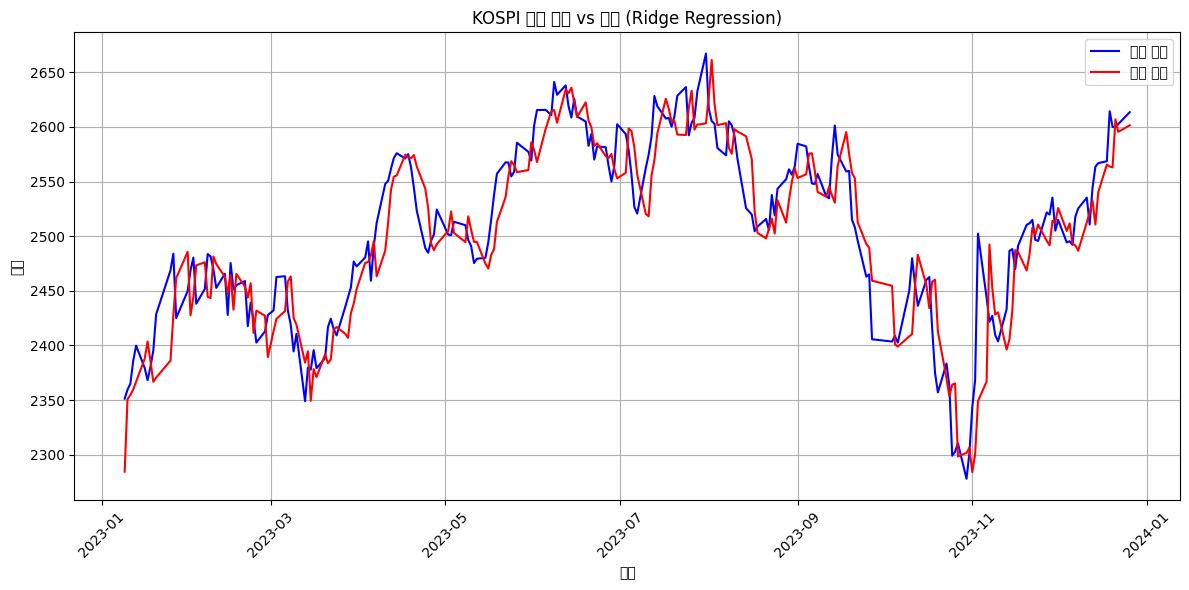

In [79]:
# 예측 결과 시각화
y_pred = best_model.predict(X_test_scaled)

# 마지막 행 제거로 길이 맞추기
dates = test_features['Date'].iloc[:-1]
y_test_aligned = y_test.values[:-1]
y_pred_aligned = y_pred[:-1]

plt.figure(figsize=(12, 6))
plt.plot(dates, y_test_aligned, label='실제 종가', color='blue')
plt.plot(dates, y_pred_aligned, label='예측 종가', color='red')
plt.title(f'KOSPI 종가 예측 vs 실제 ({best_model_name})')
plt.xlabel('날짜')
plt.ylabel('종가')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('part1_model_prediction.png')
plt.show()

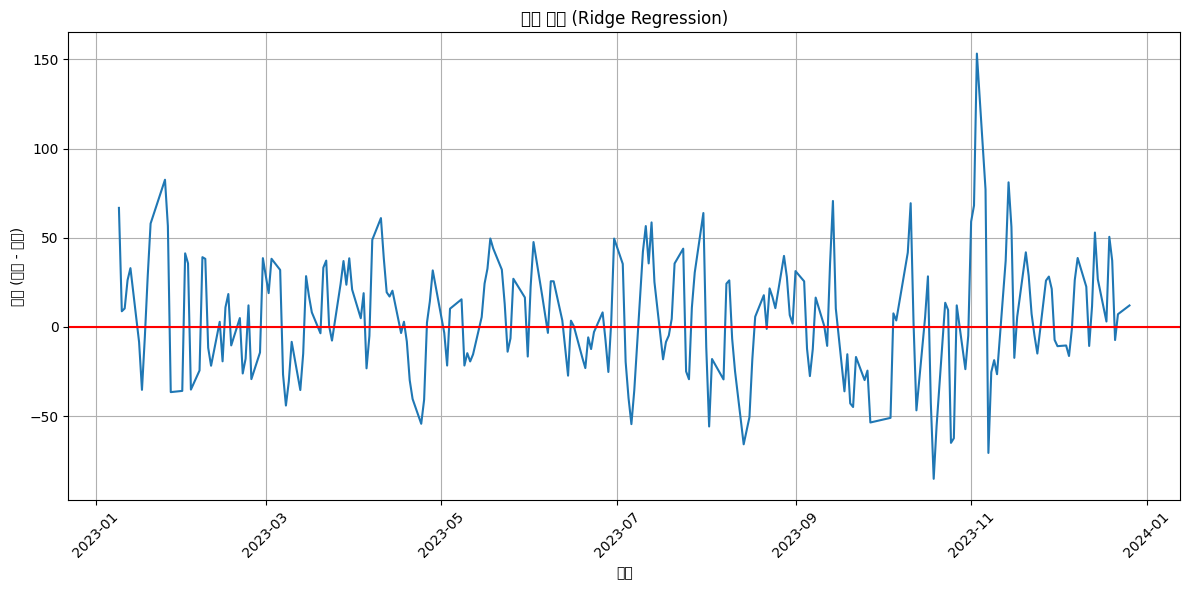

In [80]:
# 예측 오차 시각화
y_pred = best_model.predict(X_test_scaled)

# 마지막 행 제거로 길이 맞추기
dates = test_features['Date'].iloc[:-1]
y_test_aligned = y_test.values[:-1]
y_pred_aligned = y_pred[:-1]

# 오차 계산
errors = y_test_aligned - y_pred_aligned

plt.figure(figsize=(12, 6))
plt.plot(dates, errors)
plt.axhline(y=0, color='r', linestyle='-')
plt.title(f'예측 오차 ({best_model_name})')
plt.xlabel('날짜')
plt.ylabel('오차 (실제 - 예측)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('part1_prediction_errors.png')
plt.show()

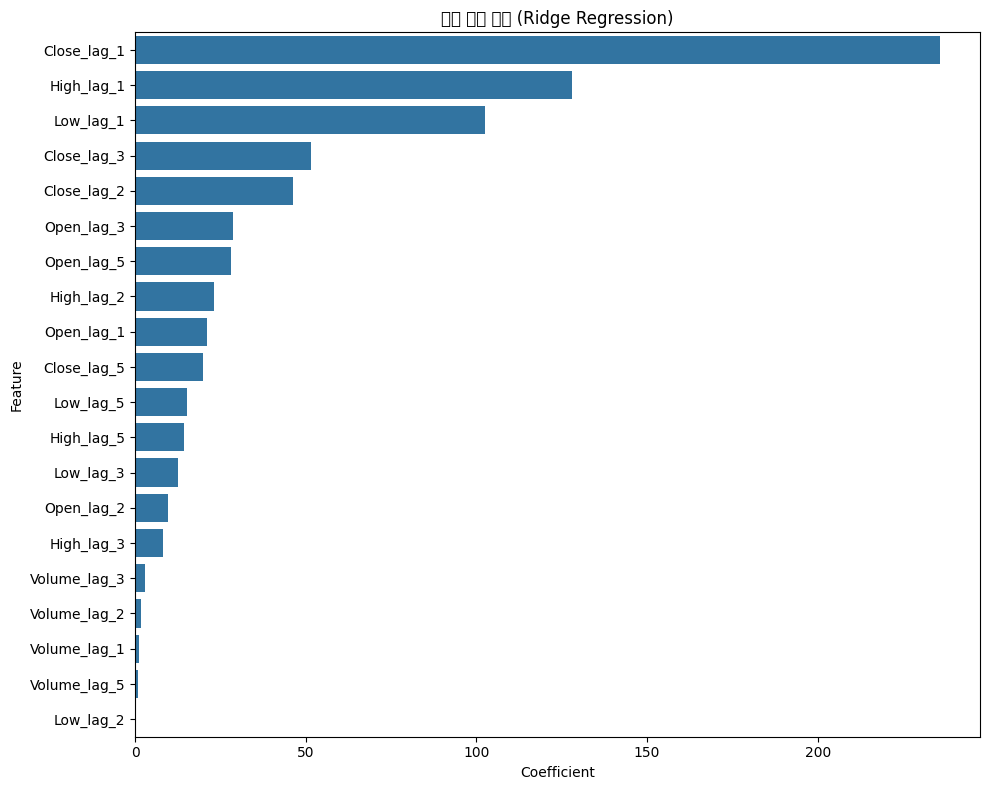


특성 계수:
         Feature  Coefficient
3    Close_lag_1   235.778411
1     High_lag_1   127.940271
2      Low_lag_1   102.524795
13   Close_lag_3    51.489648
8    Close_lag_2    46.298581
10    Open_lag_3    28.631218
15    Open_lag_5    28.195977
6     High_lag_2    23.161581
0     Open_lag_1    20.953941
18   Close_lag_5    19.803004
17     Low_lag_5    15.221526
16    High_lag_5    14.326423
12     Low_lag_3    12.636700
5     Open_lag_2     9.696754
11    High_lag_3     8.275053
14  Volume_lag_3     2.800526
9   Volume_lag_2     1.653486
4   Volume_lag_1     1.246714
19  Volume_lag_5     0.784583
7      Low_lag_2     0.049498


In [81]:
# 모델 계수 또는 특성 중요도 시각화
if hasattr(best_model, 'feature_importances_'):  # 트리 기반 모델
    feature_importances = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(10, 8))
    sns.barplot(x='Importance', y='Feature', data=feature_importances)
    plt.title(f'특성 중요도 ({best_model_name})')
    plt.tight_layout()
    plt.savefig('part1_feature_importance.png')
    plt.show()
    
    print("\n특성 중요도:")
    print(feature_importances)
    
elif hasattr(best_model, 'coef_'):  # 선형 모델
    # 계수의 절댓값을 중요도로 사용
    coefficients = pd.DataFrame({
        'Feature': X_train.columns,
        'Coefficient': np.abs(best_model.coef_)  # 절댓값 사용
    }).sort_values('Coefficient', ascending=False)
    
    plt.figure(figsize=(10, 8))
    sns.barplot(x='Coefficient', y='Feature', data=coefficients)
    plt.title(f'특성 계수 크기 ({best_model_name})')
    plt.tight_layout()
    plt.savefig('part1_feature_coefficients.png')
    plt.show()
    
    print("\n특성 계수:")
    print(coefficients)

In [82]:
# 모델 저장
import joblib
joblib.dump(best_model, 'kospi_part1_model.pkl')
joblib.dump(scaler, 'kospi_part1_scaler.pkl')
print(f"\n최고 성능 모델 '{best_model_name}' 저장 완료: 'kospi_part1_model.pkl'")


최고 성능 모델 'Ridge Regression' 저장 완료: 'kospi_part1_model.pkl'


## Part 2. Use more predictors to improve your model.

### Extend the regression model by adding some extra features of your choice. You can use any statistics publicly available. 

In [83]:
def create_technical_features(df):
    """
    기술적 분석 지표 생성 함수
    """
    # 이동평균선
    df['MA5'] = df['Close'].rolling(window=5).mean()
    df['MA20'] = df['Close'].rolling(window=20).mean()
    df['MA60'] = df['Close'].rolling(window=60).mean()
    
    # 일별 변동성
    df['Daily_Return'] = df['Close'].pct_change()
    df['Volatility'] = df['Daily_Return'].rolling(window=20).std()
    
    # RSI (상대강도지수)
    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df['RSI'] = 100 - (100 / (1 + rs))
    
    # 모멘텀
    df['Momentum'] = df['Close'].pct_change(periods=20)
    
    # 연속 상승/하락일 수
    df['Consecutive_Up_Days'] = df['Close'].diff().gt(0).rolling(window=10).sum()
    df['Consecutive_Down_Days'] = df['Close'].diff().lt(0).rolling(window=10).sum()
    
    # 볼린저 밴드
    df['Bollinger_Middle'] = df['Close'].rolling(window=20).mean()
    df['Bollinger_Upper'] = df['Bollinger_Middle'] + 2 * df['Close'].rolling(window=20).std()
    df['Bollinger_Lower'] = df['Bollinger_Middle'] - 2 * df['Close'].rolling(window=20).std()
    
    return df


In [84]:
def prepare_part2_features(train_df, test_df):
    # 날짜 변환 (이미 되어있다면 제거)
    train_df['Date'] = pd.to_datetime(train_df['Date'], format='%Y-%m-%d')
    test_df['Date'] = pd.to_datetime(test_df['Date'], format='%Y-%m-%d')

    # 특성 생성
    train_features = create_technical_features(train_df.copy())
    test_features = create_technical_features(test_df.copy())
    
    # 다음 날 종가를 타겟으로 설정
    train_features['Target'] = train_features['Close'].shift(-1)
    test_features['Target'] = test_features['Close'].shift(-1)
    
    # 이전 Part의 특성 + 새로운 특성
    part2_features = [
        # 기존 특성
        'Open_lag_1', 'High_lag_1', 'Low_lag_1', 'Close_lag_1', 'Volume_lag_1',
        'Open_lag_2', 'High_lag_2', 'Low_lag_2', 'Close_lag_2', 'Volume_lag_2',
        'Open_lag_3', 'High_lag_3', 'Low_lag_3', 'Close_lag_3', 'Volume_lag_3',
        'Open_lag_5', 'High_lag_5', 'Low_lag_5', 'Close_lag_5', 'Volume_lag_5',
        # 새로운 특성
        'MA5', 'MA20', 'MA60', 
        'Daily_Return', 'Volatility', 
        'RSI', 
        'Momentum', 
        'Consecutive_Up_Days', 'Consecutive_Down_Days',
        'Bollinger_Middle', 'Bollinger_Upper', 'Bollinger_Lower'
    ]
    
    # 이전 날짜의 OHLCV 특성 생성
    lags = [1, 2, 3, 5]
    for lag in lags:
        for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
            train_features[f'{col}_lag_{lag}'] = train_features[col].shift(lag)
            test_features[f'{col}_lag_{lag}'] = test_features[col].shift(lag)
    
    # NaN 값 제거
    train_features.dropna(subset=part2_features + ['Target'], inplace=True)
    test_features.dropna(subset=part2_features + ['Target'], inplace=True)
    
    # 특성과 타겟 분리
    X_train = train_features[part2_features]
    y_train = train_features['Target']
    X_test = test_features[part2_features]
    y_test = test_features['Target']
    
    return X_train, y_train, X_test, y_test, train_features, test_features


In [85]:
def scale_features(X_train, X_test):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled, scaler


In [86]:
def evaluate_model(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"{model_name} 성능:")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"R^2: {r2:.4f}")
    
    return {'mse': mse, 'rmse': rmse, 'mae': mae, 'r2': r2}


In [87]:
def time_series_cv(model, X, y, n_splits=5):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    cv_scores = cross_val_score(model, X, y, cv=tscv, scoring='neg_mean_squared_error')
    return -cv_scores.mean()


In [88]:
def train_and_evaluate_models(X_train, y_train, X_test, y_test):
    models = {
        'Ridge Regression': Ridge(alpha=1.0),
        'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
    }
    
    results = {}
    best_model = None
    best_score = float('inf')
    
    for name, model in models.items():
        print(f"\n{name} 모델 훈련 중...")
        
        # 시계열 교차 검증
        cv_score = time_series_cv(model, X_train, y_train)
        print(f"교차 검증 MSE: {cv_score:.2f}")
        
        # 전체 훈련 데이터로 모델 훈련
        model.fit(X_train, y_train)
        
        # 테스트 데이터로 예측
        y_pred = model.predict(X_test)
        
        # 모델 평가
        eval_results = evaluate_model(y_test, y_pred, name)
        results[name] = eval_results
        
        # 최고 성능 모델 저장
        if eval_results['mse'] < best_score:
            best_score = eval_results['mse']
            best_model = (name, model)
    
    return results, best_model

In [89]:
def visualize_prediction_results(test_features, y_test, best_model, X_test_scaled, model_name):
    # 예측값 계산
    y_pred = best_model.predict(X_test_scaled)
    
    # 마지막 행 제거로 길이 맞추기
    dates = test_features['Date'].iloc[:-1]
    y_test_aligned = y_test.values[:-1]
    y_pred_aligned = y_pred[:-1]
    
    # 예측 결과 시각화
    plt.figure(figsize=(12, 6))
    plt.plot(dates, y_test_aligned, label='실제 종가', color='blue')
    plt.plot(dates, y_pred_aligned, label='예측 종가', color='red')
    plt.title(f'KOSPI 종가 예측 vs 실제 ({model_name})')
    plt.xlabel('날짜')
    plt.ylabel('종가')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('part2_model_prediction.png')
    plt.show()
    
    return y_test_aligned, y_pred_aligned, dates

# # 함수 호출 방식 수정
# y_test_aligned, y_pred_aligned, dates = visualize_prediction_results(
#     test_features, y_test, best_model, X_test_scaled, 'Ridge Regression'
# )

In [90]:
def visualize_prediction_errors(y_test_aligned, y_pred_aligned, dates, best_model_name):
    # 예측 오차 시각화
    errors = y_test_aligned - y_pred_aligned
    
    plt.figure(figsize=(12, 6))
    plt.plot(dates, errors)
    plt.axhline(y=0, color='r', linestyle='-')
    plt.title(f'예측 오차 ({best_model_name})')
    plt.xlabel('날짜')
    plt.ylabel('오차 (실제 - 예측)')
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('part2_prediction_errors.png')
    plt.show()
    
    return errors
    
# # 함수 호출 시 모델 이름을 직접 문자열로 전달
# errors = visualize_prediction_errors(
#     y_test_aligned, y_pred_aligned, dates, 'Ridge Regression'
# )

In [91]:
def visualize_predictions(test_features, y_test, best_model, X_test_scaled, model_name, **kwargs):
    # 기존 두 시각화 함수를 호출
    y_test_aligned, y_pred_aligned, dates = visualize_prediction_results(
        test_features, y_test, best_model[1], X_test_scaled, model_name
    )
    
    # 오차 시각화
    visualize_prediction_errors(y_test_aligned, y_pred_aligned, dates, model_name)
    
    return y_test_aligned, y_pred_aligned, dates


=== Part 2: 추가 특성을 활용한 KOSPI 종가 예측 ===

사용된 특성:
['Open_lag_1', 'High_lag_1', 'Low_lag_1', 'Close_lag_1', 'Volume_lag_1', 'Open_lag_2', 'High_lag_2', 'Low_lag_2', 'Close_lag_2', 'Volume_lag_2', 'Open_lag_3', 'High_lag_3', 'Low_lag_3', 'Close_lag_3', 'Volume_lag_3', 'Open_lag_5', 'High_lag_5', 'Low_lag_5', 'Close_lag_5', 'Volume_lag_5', 'MA5', 'MA20', 'MA60', 'Daily_Return', 'Volatility', 'RSI', 'Momentum', 'Consecutive_Up_Days', 'Consecutive_Down_Days', 'Bollinger_Middle', 'Bollinger_Upper', 'Bollinger_Lower']

Ridge Regression 모델 훈련 중...
교차 검증 MSE: 2428.62
Ridge Regression 성능:
MSE: 587.04
RMSE: 24.23
MAE: 18.22
R^2: 0.8970

Random Forest 모델 훈련 중...
교차 검증 MSE: 52045.02
Random Forest 성능:
MSE: 1653.32
RMSE: 40.66
MAE: 32.38
R^2: 0.7100


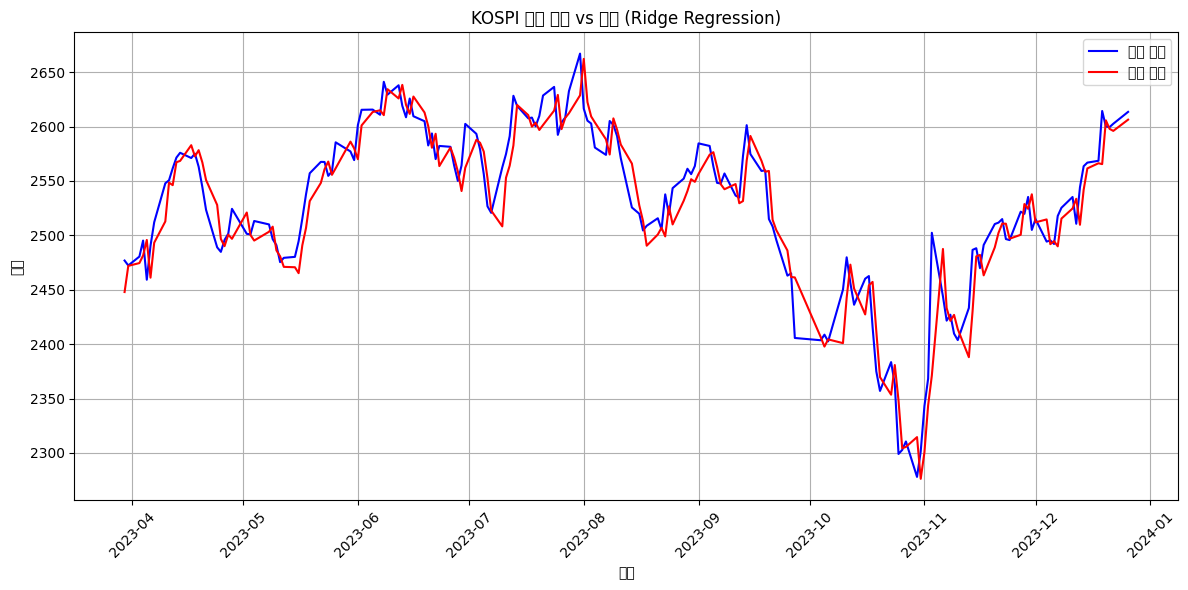

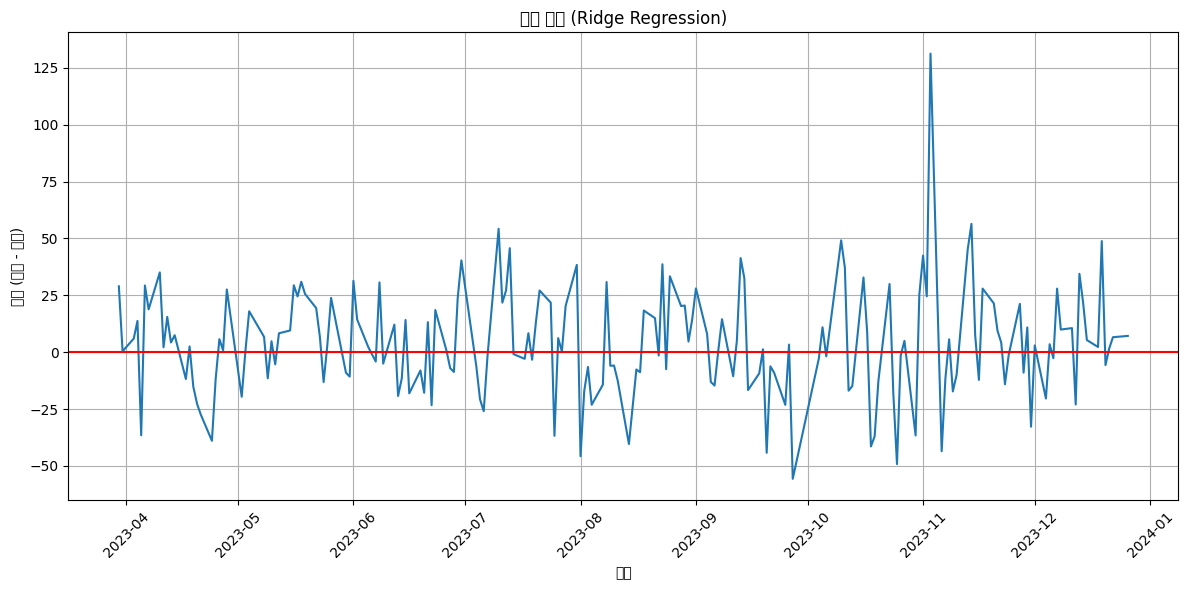


최고 성능 모델 'Ridge Regression' 저장 완료: 'kospi_part2_model.pkl'


In [92]:

# 메인 실행 부분
print("\n=== Part 2: 추가 특성을 활용한 KOSPI 종가 예측 ===")

# 데이터 로드
df_train = pd.read_csv('kospi_train.csv')
df_test = pd.read_csv('kospi_test.csv')

# 특성 준비
X_train, y_train, X_test, y_test, train_features, test_features = prepare_part2_features(df_train, df_test)

print("\n사용된 특성:")
print(X_train.columns.tolist())

# 스케일링
X_train_scaled, X_test_scaled, scaler = scale_features(X_train, X_test)

# 모델 훈련 및 평가
results, best_model = train_and_evaluate_models(X_train_scaled, y_train, X_test_scaled, y_test)

# 시각화
visualize_predictions(test_features, y_test, best_model, X_test_scaled, best_model[0], X_train=X_train)

# 모델 저장
import joblib
joblib.dump(best_model[1], 'kospi_part2_model.pkl')
joblib.dump(scaler, 'kospi_part2_scaler.pkl')
print(f"\n최고 성능 모델 '{best_model[0]}' 저장 완료: 'kospi_part2_model.pkl'")